<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/PCA%20algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (26669, 30)

First 5 rows:
  manufacturer_name model_name transmission   color  odometer_value  \
0            Subaru    Outback    automatic  silver          190000   
1            Subaru    Outback    automatic    blue          290000   
2            Subaru   Forester    automatic     red          402000   
3            Subaru    Impreza   mechanical    blue           10000   
4            Subaru     Legacy    automatic   black          280000   

   year_produced engine_fuel engine_has_gas engine_type  engine_capacity  ...  \
0           2010    gasoline          False    gasoline              2.5  ...   
1           2002    gasoline          False    gasoline              3.0  ...   
2           2001    gasoline          False    gasoline              2.5  ...   
3           1999    gasoline          False    gasoline              3.0  ...   
4           2001    gasoline          False    gasoline              2.5  ...   

  feature_1 feature_2 feature_3 feature_4  f

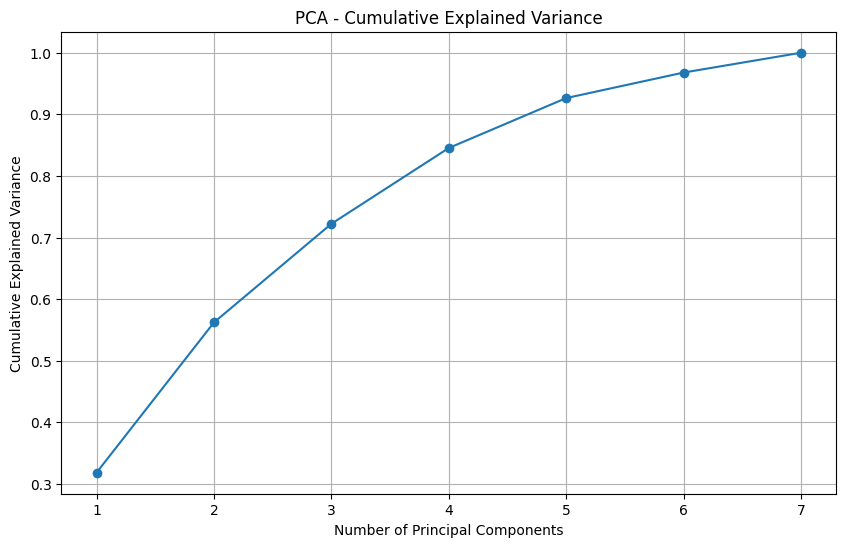


Original Number of Features: 7
Number of PCA Components for 95% Variance: 6
Reduced Data Shape: (26669, 6)

PCA Dataset:
        PC1       PC2       PC3       PC4       PC5       PC6
0  1.224591 -0.565400  0.620772 -0.661032 -0.004467  0.391949
1  0.236793  0.907900  1.533024 -0.007267 -0.467794  0.616686
2 -0.842172  1.678009  0.733106 -0.712466  0.525499  0.634033
3  1.239701  0.502172  0.709075 -0.944505 -1.934639  0.376546
4 -0.350947 -0.376919  1.036233  0.600813 -0.522036  0.252366

PCA Component Loadings:
     odometer_value  year_produced  engine_capacity  price_usd  \
PC1       -0.423497       0.561099         0.153674   0.591320   
PC2        0.116751      -0.161033         0.135619  -0.072394   
PC3        0.450344      -0.141738         0.814183   0.169970   
PC4        0.162361      -0.113839        -0.328726  -0.182801   
PC5        0.758864       0.481333        -0.332554   0.238384   
PC6        0.009319       0.065354         0.028606  -0.038029   

     number_of_pho

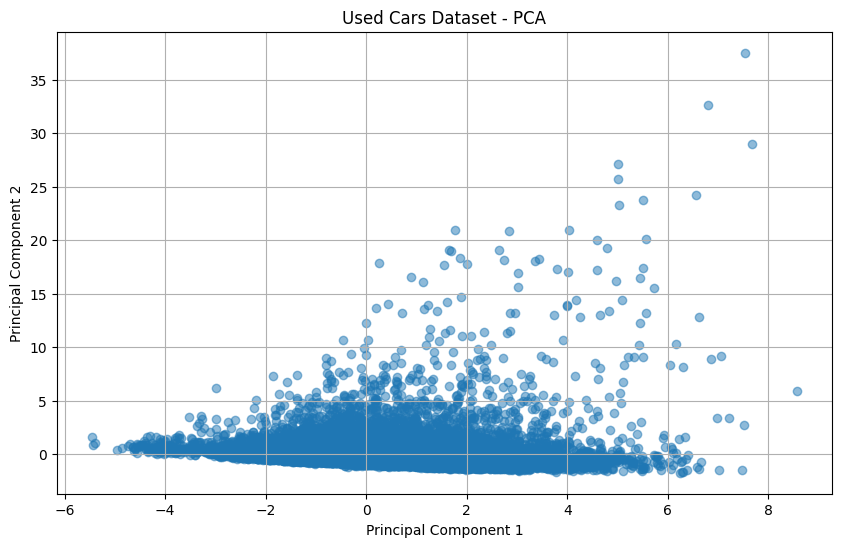


PCA dataset saved as: used_cars_PCA.csv


In [8]:
# ============================================
# PCA - Used Cars Catalog Dataset
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================
# 2. Load dataset
# ============================================

# Change the file name if your CSV has a different name
df = pd.read_csv("cars.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================
# 3. Check missing values
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================
# 4. Select numerical columns
# ============================================

numeric_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(numeric_columns.tolist())


# Create numerical dataframe
X = df[numeric_columns].copy()


# ============================================
# 5. Handle missing values
# ============================================

X = X.fillna(X.median())


# ============================================
# 6. Remove ID-like columns
# ============================================

# ID columns normally should not be used for PCA
id_columns = [
    "id",
    "car_id",
    "unnamed: 0"
]

for column in id_columns:
    if column in X.columns:
        X = X.drop(column, axis=1)


print("\nFeatures used for PCA:")
print(X.columns.tolist())


# ============================================
# 7. Standardize the data
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:")
print(X_scaled.shape)


# ============================================
# 8. Apply PCA
# ============================================

# First calculate all components
pca = PCA()

X_pca = pca.fit_transform(X_scaled)


# ============================================
# 9. Explained Variance
# ============================================

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
for i, variance in enumerate(explained_variance):
    print(
        f"PC{i+1}: {variance * 100:.2f}%"
    )


# ============================================
# 10. Cumulative Explained Variance
# ============================================

cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Explained Variance:")

for i, variance in enumerate(cumulative_variance):
    print(
        f"PC{i+1}: {variance * 100:.2f}%"
    )


# ============================================
# 11. Plot Explained Variance
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")

plt.grid()
plt.show()


# ============================================
# 12. Choose components
# ============================================

# Keep enough components to explain 95% variance
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("\nOriginal Number of Features:", X.shape[1])

print(
    "Number of PCA Components for 95% Variance:",
    pca_95.n_components_
)

print(
    "Reduced Data Shape:",
    X_pca_95.shape
)


# ============================================
# 13. Create PCA DataFrame
# ============================================

pca_columns = [
    f"PC{i+1}"
    for i in range(pca_95.n_components_)
]

pca_df = pd.DataFrame(
    X_pca_95,
    columns=pca_columns
)

print("\nPCA Dataset:")
print(pca_df.head())


# ============================================
# 14. PCA Component Loadings
# ============================================

loadings = pd.DataFrame(
    pca_95.components_,
    columns=X.columns,
    index=pca_columns
)

print("\nPCA Component Loadings:")
print(loadings)


# ============================================
# 15. Visualize first two principal components
# ============================================

if X_pca_95.shape[1] >= 2:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        X_pca_95[:, 0],
        X_pca_95[:, 1],
        alpha=0.5
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.title(
        "Used Cars Dataset - PCA"
    )

    plt.grid()
    plt.show()


# ============================================
# 16. Save PCA dataset
# ============================================

pca_df.to_csv(
    "used_cars_PCA.csv",
    index=False
)

print("\nPCA dataset saved as: used_cars_PCA.csv")